In [1]:
from fyers_apiv3 import fyersModel
import webbrowser
from datetime import datetime, timedelta
import pandas as pd

In [2]:
app_id = "NLRNTA5OZE-100"
client_id = "YV01955"
secret_key = "YDK19LYJP2"
redirect_uri = "https://trade.fyers.in/api-login/redirect-uri/index.html"
# redirect_uri= "https://fyers.in/"  ## redircet_uri you entered while creating APP.
response_type = "code"
state = "sample_state"
grant_type = "authorization_code"
log_path = "E:/Algo/Flyers/Logs/"

In [5]:
appSession = fyersModel.SessionModel(client_id = app_id, redirect_uri = redirect_uri,response_type=response_type,state=state,secret_key=secret_key,grant_type=grant_type)
generateTokenUrl = appSession.generate_authcode()
print((generateTokenUrl))
webbrowser.open(generateTokenUrl,new=1)

https://api-t1.fyers.in/api/v3/generate-authcode?client_id=NLRNTA5OZE-100&redirect_uri=https%3A%2F%2Ftrade.fyers.in%2Fapi-login%2Fredirect-uri%2Findex.html&response_type=code&state=sample_state


True

In [6]:
# auth_code = "eyJhbGciOiJIUzI1NiIsInR5cCI6IkpXVCJ9.eyJhcHBfaWQiOiJOTFJOVEE1T1pFIiwidXVpZCI6IjYzNzE0ZDA5NmYzYjQyNGFhZWQwNGY4NGNkZDM3MDYzIiwiaXBBZGRyIjoiIiwibm9uY2UiOiIiLCJzY29wZSI6IiIsImRpc3BsYXlfbmFtZSI6IllWMDE5NTUiLCJvbXMiOiJLMSIsImhzbV9rZXkiOiI5ZTUyYjRjOTI2NjNiNjE5Y2I5Mzg1MGI3ZjQ1ZWVkZDNiMTgzZjIyNjNiYjJhYmE5YTM3ZTI3NCIsImlzRGRwaUVuYWJsZWQiOiJOIiwiaXNNdGZFbmFibGVkIjoiTiIsImF1ZCI6IltcImQ6MVwiLFwiZDoyXCIsXCJ4OjBcIixcIng6MVwiLFwieDoyXCJdIiwiZXhwIjoxNzU5OTc1MTg3LCJpYXQiOjE3NTk5NDUxODcsImlzcyI6ImFwaS5sb2dpbi5meWVycy5pbiIsIm5iZiI6MTc1OTk0NTE4Nywic3ViIjoiYXV0aF9jb2RlIn0.y0KcsUZLPY9miG13dSAEN5tL4fgI-AUtwa6hJ89QIK8"
auth_code = input()
appSession.set_token(auth_code)
response = appSession.generate_token()
try: 
    access_token = response["access_token"]
    print("login successfull")
except Exception as e:
    print(e,response)

login successfull


In [7]:
fyers = fyersModel.FyersModel(token=access_token,is_async=False,client_id=app_id,log_path= log_path)

In [8]:
# data_fetcher.py
from datetime import datetime, timedelta
import pandas as pd


def extract_historical_data(fyers, symbol, window, range_from, range_to):
    symbol = 'NSE:'+symbol.upper()+'-EQ'
    start = datetime.strptime(range_from, "%Y-%m-%d").date()
    end = datetime.strptime(range_to, "%Y-%m-%d").date()
    def same_day_data(fyers, symbol, window, range_from, range_to):
        input_data = {"symbol":symbol,"resolution": window, "date_format":"1", "range_from": range_from, "range_to": range_to, "cont_flag":"1"}
        fetched = fyers.history(input_data)
        candles = pd.DataFrame(fetched['candles'], columns=['ts','open','high','low','close','vol'])
        candles['ts'] = candles['ts'].map(datetime.fromtimestamp)
        return candles

    def extract_past_data(fyers, symbol, window, range_from, range_to):
        range_from_dt = datetime.strptime(range_from, "%Y-%m-%d")
        range_to_dt = datetime.strptime(range_to, "%Y-%m-%d")
        candles = pd.DataFrame()
        if window in ['1','2','5','10','15','30','60','D','1D','1W','1M']:
            for i in range(0,10000,20):
                _from = range_from_dt + timedelta(days=i)
                new_date = _from + timedelta(days=20)
                if new_date <= range_to_dt:
                    range_from_str = _from.strftime("%Y-%m-%d")
                    range_to_str = new_date.strftime("%Y-%m-%d")
                    input_data = {
                        "symbol": symbol,
                        "resolution": window, 
                        "date_format": "1", 
                        "range_from": range_from_str,
                        "range_to": range_to_str, 
                        "cont_flag": "1"
                    }
                    fetched = fyers.history(input_data)
                    if 'candles' in fetched:
                        candle = pd.DataFrame(fetched['candles'], columns=['ts','open','high','low','close','vol'])
                        candle['ts'] = candle['ts'].map(datetime.fromtimestamp)
                        candles = pd.concat([candles, candle], axis=0)
                else:
                    break
        return candles
    if window in ['D','1D','1W','1M']:
        return extract_past_data(fyers, symbol, window, range_from, range_to)
    elif ((end - start).days > 62) & (window in ['1','2','5','10','15','30','60']):
        return None
    elif ((end - start).days > 20) & (window in ['1','2','5','10','15','30','60']):
        return extract_past_data(fyers, symbol, window, range_from, range_to)
    elif ((end - start).days <= 20) & (window in ['1','2','5','10','15','30','60']):
        return same_day_data(fyers, symbol, window, range_from, range_to)
    else:
        raise ValueError("Invalid parameters: Ensure that the date range does not exceed 20 days for intraday data.")
        

In [ ]:
def extract_data_for_multiple_symbols(fyers, symbols, window, range_from, range_to):
    all_data = pd.DataFrame()
    for symbol in symbols:
        data = extract_historical_data(fyers, symbol, window, range_from, range_to)
        all_data = pd.concat([all_data,data], axis=0)
    return all_data


AttributeError: type object 'datetime.datetime' has no attribute 'datetime'

In [14]:
import pandas as pd
import pandas_ta as ta
import numpy as np

# --- Part 1: Daily Logic Functions ---

def calculate_daily_indicators(df_daily):
    """Calculates all required daily indicators (RSI, ADX, StochRSI, SMAs) and adds them to the DataFrame."""
    
    # Ensure the DataFrame has the correct column names for pandas_ta
    # (typically 'Open', 'High', 'Low', 'Close', 'Volume').
    # Assuming your daily OHLC data is in a DataFrame called df_daily
    
    # Relative Strength Index (RSI) with a 21-period setting
    df_daily.ta.rsi(length=21, append=True) # Creates 'RSI_21' column
    
    # Average Directional Index (ADX) with a 14-period setting
    # ADX calculation also creates 'DMP_14', 'DMN_14', and 'ADX_14'
    df_daily.ta.adx(length=14, append=True) # Creates 'ADX_14' column
    
    # StochRSI (14 periods) - default settings often use 14,3,3
    # This will typically create columns like 'STOCHRSIk_14_3_3' and 'STOCHRSId_14_3_3'
    # We will use the main StochRSI value, often named 'STOCHRSIk_14_3_3' (or similar k-line)
    df_daily.ta.stochrsi(length=14, append=True)
    
    # Simple Moving Averages (SMAs)
    df_daily.ta.sma(length=200, append=True) # Creates 'SMA_200' column
    df_daily.ta.sma(length=50, append=True)  # Creates 'SMA_50' column
    df_daily.ta.sma(length=20, append=True)  # Creates 'SMA_20' column
    
    return df_daily.copy()


def check_daily_logics(df_daily):
    """
    Checks the daily price action and indicator logics for the last available day.
    
    df_daily is expected to be a DataFrame with OHLCV data,
    including the calculated indicators from calculate_daily_indicators.
    """
    
    if len(df_daily) < 2:
        return {"Overall_Daily_Logic_Pass": False, "Reason": "Not enough data for previous day calculations."}

    # Get the data for the current day (last row) and previous day (second to last row)
    current = df_daily.iloc[-1]
    previous = df_daily.iloc[-2]
    
    # Calculate the average price for the previous day (P_prev)
    P_prev = (previous['High'] + previous['Low'] + previous['Close']) / 3.0
    
    # --- Logic 1: Twice average previous (H, L, C) minus previous low < current low ---
    logic_1 = (2 * P_prev - previous['Low']) < current['Low']
    
    # --- Logic 2: Average previous (H, L, C) < current close ---
    logic_2 = P_prev < current['Close']
    
    # --- Logic 4: Daily RSI (21) >= 60 ---
    # The exact column name depends on the pandas_ta output. We assume 'RSI_21'
    rsi_col = 'RSI_21'
    logic_4 = current.get(rsi_col, -1) >= 60

    # --- Logic 5: Daily ADX (14) >= 20 ---
    # The exact column name depends on the pandas_ta output. We assume 'ADX_14'
    adx_col = 'ADX_14'
    logic_5 = current.get(adx_col, -1) >= 20

    # --- Logic 6: Daily Close > SMA (200) ---
    sma_200_col = 'SMA_200'
    logic_6 = current['Close'] > current.get(sma_200_col, -1)

    # --- Logic 7: Daily Close > SMA (50) ---
    sma_50_col = 'SMA_50'
    logic_7 = current['Close'] > current.get(sma_50_col, -1)
    
    # --- Logic 8: Daily Close > SMA (20) ---
    sma_20_col = 'SMA_20'
    logic_8 = current['Close'] > current.get(sma_20_col, -1)

    # --- Logic 9: Daily StochRSI (14) k-line > 70 ---
    # StochRSI k-line is typically the primary line to check for overbought/oversold.
    # The default pandas_ta name is often STOCHRSIk_14_3_3 or similar
    stochrsi_k_col = df_daily.filter(regex='STOCHRSIk_14').columns[0] if df_daily.filter(regex='STOCHRSIk_14').shape[1] > 0 else None
    logic_9 = current.get(stochrsi_k_col, -1) > 70

    # Combine all daily logics
    all_daily_logics = logic_1 and logic_2 and logic_4 and logic_5 and logic_6 and logic_7 and logic_8 and logic_9
    
    results = {
        "Logic_1": logic_1,
        "Logic_2": logic_2,
        "Logic_4": logic_4,
        "Logic_5": logic_5,
        "Logic_6": logic_6,
        "Logic_7": logic_7,
        "Logic_8": logic_8,
        "Logic_9": logic_9,
        "All_Daily_Logics_Pass": all_daily_logics
    }
    
    return results

# --- Part 2: Intraday VWAP Logic Function ---

def check_intraday_vwap_logic(df_intraday, last_hour_minutes=60):
    """
    Checks if the current price is greater than the VWAP of the last hour.

    df_intraday is expected to be a DataFrame with High, Low, Close, and Volume 
    at a high frequency (e.g., 1-minute bars) with a Datetime Index.
    """
    if df_intraday.empty:
        return False, {"Reason": "Intraday data is empty."}
    
    # Get the data for the last 'last_hour_minutes' (e.g., 60 minutes)
    df_last_hour = df_intraday.iloc[-last_hour_minutes:].copy()
    
    if len(df_last_hour) < 1:
        return False, {"Reason": f"Less than {last_hour_minutes} data points for the last hour."}

    # Calculate Typical Price (TP) for each bar in the last hour
    # TP = (High + Low + Close) / 3
    df_last_hour['TP'] = (df_last_hour['High'] + df_last_hour['Low'] + df_last_hour['Close']) / 3.0
    
    # Calculate Price * Volume (PV)
    df_last_hour['PV'] = df_last_hour['TP'] * df_last_hour['Volume']
    
    # The VWAP for the entire last hour is the cumulative PV divided by cumulative Volume
    # for the last point in the hour.
    
    # Sum of (Price * Volume) for the last hour
    sum_pv = df_last_hour['PV'].sum()
    
    # Sum of Volume for the last hour
    sum_volume = df_last_hour['Volume'].sum()
    
    if sum_volume == 0:
        return False, {"Reason": "Volume for the last hour is zero, cannot calculate VWAP."}

    # Calculate the VWAP for the last hour
    vwap_last_hour = sum_pv / sum_volume
    
    # Current price is the close price of the very last bar
    current_price = df_intraday['Close'].iloc[-1]
    
    # --- Logic 3: Current price > VWAP of that hour ---
    logic_3_pass = current_price > vwap_last_hour
    
    vwap_details = {
        "VWAP_Last_Hour": vwap_last_hour,
        "Current_Price": current_price,
        "Logic_3": logic_3_pass
    }
    
    return logic_3_pass, vwap_details

# --- Part 3: Main Execution Function ---

def run_all_logics(df_daily, df_intraday):
    """
    Runs all 9 logics on the provided daily and intraday DataFrames.
    
    df_daily: DataFrame with daily OHLCV data.
    df_intraday: DataFrame with high-frequency OHLCV data (e.g., 1-minute bars) 
                 for the current trading session, used for VWAP.
    """
    
    # 1. Calculate Daily Indicators
    df_daily_with_indicators = calculate_daily_indicators(df_daily)
    
    # 2. Check Daily Logics (1, 2, 4, 5, 6, 7, 8, 9)
    daily_results = check_daily_logics(df_daily_with_indicators)
    daily_pass = daily_results.get("All_Daily_Logics_Pass", False)
    
    # 3. Check Intraday VWAP Logic (3)
    # Assuming df_intraday contains the data for the last 60 minutes needed for the calculation
    intraday_pass, vwap_details = check_intraday_vwap_logic(df_intraday, last_hour_minutes=60)
    
    # 4. Final Combination
    all_logics_pass = daily_pass and intraday_pass
    
    final_report = {
        "Daily_Checks": daily_results,
        "VWAP_Check": vwap_details,
        "Logic_3_Pass": intraday_pass,
        "Overall_Pass": all_logics_pass
    }
    
    return final_report

# --- Example Usage ---

# 1. Create Mock Daily Data (Need a large enough DataFrame for 200-day SMA, RSI, ADX)
# In a real scenario, you would load this from a file or API.
dates_daily = pd.date_range(start='2024-01-01', periods=300, freq='D')
np.random.seed(42)
daily_data = {
    'Open': np.random.uniform(90, 100, 300).cumsum() + 100,
    'High': (np.random.uniform(90, 100, 300).cumsum() + 100) * 1.01,
    'Low': (np.random.uniform(90, 100, 300).cumsum() + 100) * 0.99,
    'Close': np.random.uniform(90, 100, 300).cumsum() + 100,
    'Volume': np.random.randint(100000, 500000, 300)
}
df_daily = pd.DataFrame(daily_data, index=dates_daily)
# Ensure Close is between Low and High, and Open is plausible
df_daily['Close'] = df_daily[['Open', 'High', 'Low']].mean(axis=1) * np.random.uniform(0.99, 1.01, 300)
df_daily = df_daily.round(2)
df_daily.index.name = 'Date'


# 2. Create Mock Intraday Data (Need enough data for the last 60 minutes)
# In a real scenario, this would be 1-minute bars for the current day.
dates_intraday = pd.date_range(start='2025-10-08 09:00', periods=300, freq='T') # 300 minutes (5 hours) of data
intraday_data = {
    'Open': np.random.uniform(df_daily['Close'].iloc[-1]-1, df_daily['Close'].iloc[-1]+1, 300),
    'High': np.random.uniform(df_daily['Close'].iloc[-1]-0.5, df_daily['Close'].iloc[-1]+1.5, 300),
    'Low': np.random.uniform(df_daily['Close'].iloc[-1]-1.5, df_daily['Close'].iloc[-1]+0.5, 300),
    'Close': np.random.uniform(df_daily['Close'].iloc[-1]-1, df_daily['Close'].iloc[-1]+1, 300),
    'Volume': np.random.randint(1000, 5000, 300)
}
df_intraday = pd.DataFrame(intraday_data, index=dates_intraday)
df_intraday['Close'].iloc[-1] = df_intraday['High'].iloc[-60:].max() # Manually set last close high to simulate Logic 3 passing
df_intraday.index.name = 'Datetime'
df_intraday = df_intraday.round(4)


# Execute the combined logic
results = run_all_logics(df_daily, df_intraday)

# Print the final report
print("\n--- Final Logic Check Report ---")
print(f"Overall Pass: {results['Overall_Pass']}")
print("\nDaily Logic Results (1, 2, 4-9):")
print(pd.Series(results['Daily_Checks']))
print("\nIntraday VWAP Logic Result (3):")
print(pd.Series(results['VWAP_Check']))
print(f"Logic 3 Pass: {results['Logic_3_Pass']}")


--- Final Logic Check Report ---
Overall Pass: False

Daily Logic Results (1, 2, 4-9):
Logic_1                  False
Logic_2                   True
Logic_4                   True
Logic_5                   True
Logic_6                   True
Logic_7                   True
Logic_8                   True
Logic_9                  False
All_Daily_Logics_Pass    False
dtype: bool

Intraday VWAP Logic Result (3):
VWAP_Last_Hour    28501.819147
Current_Price       28503.3009
Logic_3                   True
dtype: object
Logic 3 Pass: True


C:\Users\Dell\AppData\Local\Temp\ipykernel_23656\716889322.py:213: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  dates_intraday = pd.date_range(start='2025-10-08 09:00', periods=300, freq='T') # 300 minutes (5 hours) of data
C:\Users\Dell\AppData\Local\Temp\ipykernel_23656\716889322.py:222: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the origi

In [ ]:
print(fyers.get_profile())

{'s': 'ok', 'code': 200, 'message': '', 'data': {'fy_id': 'YV01955', 'name': 'VIJAY KUMAR', 'image': None, 'display_name': None, 'pin_change_date': '16-01-2024 09:24:24', 'email_id': 'vjfriend.b.4.u@gmail.com', 'pwd_change_date': None, 'PAN': '---------', 'mobile_number': '8178080775', 'totp': False, 'pwd_to_expire': 90}}


In [ ]:
print(fyers.funds())
print(fyers.holdings())

{'code': 200, 'message': '', 's': 'ok', 'fund_limit': [{'id': 1, 'title': 'Total Balance', 'equityAmount': 0, 'commodityAmount': 0}, {'id': 2, 'title': 'Utilized Amount', 'equityAmount': 0, 'commodityAmount': 0}, {'id': 3, 'title': 'Clear Balance', 'equityAmount': 0, 'commodityAmount': 0}, {'id': 4, 'title': 'Realized Profit and Loss', 'equityAmount': 0, 'commodityAmount': 0}, {'id': 5, 'title': 'Collaterals', 'equityAmount': 0, 'commodityAmount': 0}, {'id': 6, 'title': 'Fund Transfer', 'equityAmount': 0, 'commodityAmount': 0}, {'id': 7, 'title': 'Receivables', 'equityAmount': 0, 'commodityAmount': 0}, {'id': 8, 'title': 'Adhoc Limit', 'equityAmount': 0, 'commodityAmount': 0}, {'id': 9, 'title': 'Limit at start of the day', 'equityAmount': 0, 'commodityAmount': 0}, {'id': 10, 'title': 'Available Balance', 'equityAmount': 0, 'commodityAmount': 0}]}
{'code': 200, 'message': '', 's': 'ok', 'overall': {'count_total': 0, 'pnl_perc': 0, 'total_current_value': 0, 'total_investment': 0, 'total

In [8]:
print(fyers.tradebook())
print(fyers.orderbook())
print(fyers.positions())

{'code': 200, 'message': '', 's': 'ok', 'tradeBook': []}
{'code': 200, 'message': '', 's': 'ok', 'orderBook': []}
{'code': 200, 'message': '', 's': 'ok', 'netPositions': [], 'overall': {'count_open': 0, 'count_total': 0, 'pl_realized': 0, 'pl_total': 0, 'pl_unrealized': 0}}


In [9]:
## SINGLE ORDER 

data =  {
      "symbol":"NSE:SUNDARMFIN-EQ",
      "qty":1,
      "type":1,
      "side":1,
      "productType":"INTRADAY",
      "limitPrice":0,
      "stopPrice":0,
      "validity":"DAY",
      "disclosedQty":0,
      "offlineOrder":False,
      "stopLoss":0,
      "takeProfit":0
    }

In [10]:
print(fyers.place_order(data))

{'code': -50, 'message': 'limitPrice: Must be greater than or equal to 0.0025', 's': 'error'}


In [ ]:
data = [{ "symbol":"NSE:SBIN-EQ",
  "qty":1,
  "type":1,  
  "side":1, 
  "productType":"INTRADAY",   
  "limitPrice":61050,
  "stopPrice":0 ,
  "disclosedQty":0, 
  "validity":"DAY", 
  "offlineOrder":False, 
  "stopLoss":0,  
  "takeProfit":0
},
{
  "symbol":"NSE:HDFC-EQ",
  "qty":1,
  "type":2,  
  "side":1, 
  "productType":"INTRADAY",   
  "limitPrice":0,
  "stopPrice":0 ,
  "disclosedQty":0, 
  "validity":"DAY", 
  "offlineOrder":False, 
  "stopLoss":0,  
  "takeProfit":0
}]                                                ### This takes input as a list containing multiple single order data into it and the execution of the orders goes in the same format as mentioned.

print(fyers.place_basket_orders(data))

In [ ]:
## Modify_order request 
data = {
          "id":"7574657627567", 
          "type":1, 
          "limitPrice": 61049,
          "qty":1
      }

print(fyers.modify_order(data))

data = [
    { "id":"8102710298291",
  "type":1,
  "limitPrice": 61049,
  "qty":0
},
{
  "id":"8102710298292",
  "type":1,
  "limitPrice": 61049,
  "qty":1 
}]

print(fyers.modify_basket_orders(data))


In [ ]:
### Cancel_order
data = {"id":'808058117761'}
print(fyers.cancel_order(data))

### cancel_multi_order 
data  =  [
{ 
   "id":'808058117761'
 },
 {
   "id":'808058117762'
 }]
 
print(fyers.cancel_basket_orders(data))

In [ ]:
### Exit Position 
data  = {
     "id":"NSE:SBIN-EQ-INTRADAY"
   }

print(fyers.exit_positions(data))

In [ ]:
### Convert Position
data = {
     "symbol":"MCX:SILVERMIC20NOVFUT",
     "positionSide":1,
     "convertQty":1,
     "convertFrom":"INTRADAY",
     "convertTo":"CNC"
   }

print(fyers.convert_position(data))

In [10]:
## Historical Data 

data = {"symbol":"NSE:NIFTY2411822100CE","resolution":"30","date_format":"1","range_from":"2024-01-01","range_to":"2024-02-08"
        ,"cont_flag":"1"}

print(fyers.history(data))
# import pandas as pd
# pd.DataFrame(data)

{'code': -300, 'message': 'Invalid symbol provided', 's': 'error'}


In [8]:
def historical_data(symbol, window, range_from, range_to):
    input_data = {"symbol":symbol,"resolution": window, "date_format":"1", "range_from": range_from, "range_to": range_to, "cont_flag":"1"}
    fetched = fyers.history(input_data)
    candles = pd.DataFrame(fetched['candles'], columns=['ts','Open','High','Low','Close','Vol'])
    candles['ts'] = candles['ts'].map(datetime.fromtimestamp)
    return candles

df = historical_data(symbol="NSE:SUNDARMFIN-EQ", window= "1", range_from="2025-01-03", range_to="2025-01-03")
df.tail(50)

,ts,Open,High,Low,Close,Vol
237,2025-01-03 13:12:00,4656.30,4659.00,4656.00,4658.60,198
238,2025-01-03 13:13:00,4659.00,4660.35,4658.60,4659.90,108
239,2025-01-03 13:14:00,4659.85,4659.85,4656.90,4656.90,149
240,2025-01-03 13:15:00,4659.80,4659.80,4656.00,4658.55,83
241,2025-01-03 13:16:00,4658.50,4658.50,4656.05,4656.05,179
242,2025-01-03 13:17:00,4658.35,4660.65,4656.00,4659.45,885
243,2025-01-03 13:18:00,4656.05,4659.20,4656.05,4658.95,78
244,2025-01-03 13:19:00,4658.95,4658.95,4657.55,4658.90,185
245,2025-01-03 13:20:00,4663.00,4669.60,4663.00,4666.95,1578
246,2025-01-03 13:21:00,4661.50,4668.55,4661.50,4665.50,337


In [17]:
def historical_data(symbol, window, range_from, range_to):
    input_data = {"symbol":symbol,"resolution": window, "date_format":"1", "range_from": range_from, "range_to": range_to, "cont_flag":"1"}
    fetched = fyers.history(input_data)
    candles = pd.DataFrame(fetched['candles'], columns=['ts','Open','High','Low','Close','Vol'])
    candles['ts'] = candles['ts'].map(datetime.fromtimestamp)
    return candles

df = historical_data(symbol="NSE:WIPRO-EQ", window= "5", range_from="2024-02-07", range_to="2024-02-12")
print(df.shape)
df.head(2)
# df.to_csv('E:/OurBus/Algo/Other Scripts/Strategies/high50Low40_strategy/stock_data1.csv', index=False)

(300, 6)


,ts,Open,High,Low,Close,Vol
0,2024-02-07 09:15:00,250.48,250.85,247.93,248.38,969666
1,2024-02-07 09:20:00,248.18,248.60,247.30,248.38,437128


In [ ]:
def historical_data(symbol, window, range_from, range_to):
    rg_from = datetime.strptime(range_from, "%Y-%m-%d")
    _to = datetime.strptime(range_to, "%Y-%m-%d") + timedelta(days=200)
    candles = pd.DataFrame()
    if window in ['1D','D']:
        for i in range(0,10000,200):
            _from = rg_from + timedelta(days=i)
            new_date = _from + timedelta(days=200)
            if new_date <= _to:
                range_from = _from.strftime("%Y-%m-%d")
                range_to = new_date.strftime("%Y-%m-%d")
                input_data = {"symbol":symbol,"resolution": window, "date_format":"1", "range_from": range_from
                              , "range_to": range_to, "cont_flag":"1"}
                fetched = fyers.history(input_data)
                candle = pd.DataFrame(fetched['candles'], columns=['ts','Open','High','Low','Close','Vol'])
                candle['ts'] = candle['ts'].map(datetime.fromtimestamp)
                candles = pd.concat([candles, candle], axis=0)
            else:
                break
    return candles

df = historical_data(symbol="NSE:SBIN-EQ", window= "D", range_from="2023-01-01", range_to="2024-02-09")
print(df.shape)
df.to_csv('E:/OurBus/Algo/Other Scripts/Strategies/high50Low40_strategy/stock_data1.csv', index=False)

In [ ]:
import pandas_ta as ta
import matplotlib.pyplot as plt
from termcolor import colored as cl
import math 

In [ ]:
df = pd.read_csv('E:/OurBus/Algo/Other Scripts/Strategies/high50Low40_strategy/stock_data1.csv')
df['ts'] = pd.to_datetime(df.ts)
# df['ts'] = pd.to_datetime(df.ts.dt.date)
logic = {'Open'  : 'first',
         'High'  : 'max',
         'Low'   : 'min',
         'Close' : 'last',
         'Vol': 'sum'}

offset = timedelta(days=-6)
df.index = df['ts']
df = df.resample('W', loffset=offset).apply(logic)
df['time'] = pd.to_datetime(df.index)
df[cols]

In [ ]:
df[['dcl', 'dcm', 'dcu']] = df.ta.donchian(lower_length = 40, upper_length = 50)
df = df.dropna().rename(columns = {'ts':'date'})
df = df.set_index('date')
df.index = pd.to_datetime(df.index)
print(df.tail(2))

In [ ]:
df.shape

In [ ]:
import pandas as pd
from plotly.offline import plot
import plotly.graph_objs as go
from datetime import datetime

In [ ]:
def plotly_plot_new():
  df = historical_data(symbol="NSE:SBIN-EQ", window= "1W", range_from="2024-01-01", range_to="2024-01-16")
  open_data = df['Open']
  high_data = df['High']
  low_data = df['Low']
  close_data = df['Close']
  dates = df['ts']

  fig = go.Figure(data=[go.Candlestick(x=dates,
                         open=open_data, high=high_data,
                         low=low_data, close=close_data)])
  plotly_plot_obj = plot({'data': fig}, output_type='div')

  return fig

In [ ]:
plotly_plot_new()

In [ ]:
import pandas as pd

# Sample DataFrame creation
data = {'date': ['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-08', '2024-01-12']}
df = pd.DataFrame(data)
df['date'] = pd.to_datetime(df['date'])

# Define a custom aggregation function to find the last date in each group
def last_date(series):
    if not series.empty:
        return series.iloc[-1]

# Group by week starting on Monday and use the custom aggregation function
result_df = df.groupby(pd.Grouper(key='date', freq='W-Mon')).agg(last_date).reset_index()

print(result_df)

In [ ]:
import pandas as pd
from plotly.offline import plot
import plotly.graph_objs as go
from datetime import datetime
def plotly_plot_new():
  # access_token = fyersModel.access_token()
  # df = fyersModel.historical_data(symbol="NSE:SBIN-EQ", window= "1D", range_from="2024-01-01", range_to="2024-01-16")
  df = pd.read_csv('E:/OurBus/Algo/Other Scripts/Strategies/high50Low40_strategy/stock_data.csv')
  open_data = df['Open']
  high_data = df['High']
  low_data = df['Low']
  close_data = df['Close']
  dates = df['ts']

  fig = go.Figure(data=[go.Candlestick(x=dates,
                         open=open_data, high=high_data,
                         low=low_data, close=close_data)])
  plotly_plot_obj = plot({'data': fig}, output_type='div')

  return plotly_plot_obj
print(plotly_plot_new()[0:10000])

`Strategy Backtesting`

In [ ]:
import pandas as pd
import requests
import numpy as np
from lightweight_charts import Chart
import time
import asyncio
import nest_asyncio
nest_asyncio.apply()

import pandas_ta as ta
import matplotlib.pyplot as plt
from termcolor import colored as cl
import math 
from datetime import datetime, timedelta

plt.rcParams['figure.figsize'] = (20,10)
plt.style.use('fivethirtyeight')

In [ ]:
df = pd.read_csv('E:/OurBus/Algo/Other Scripts/Strategies/high50Low40_strategy/stock_data1.csv')
logic = {'Open'  : 'first',
         'High'  : 'max',
         'Low'   : 'min',
         'Close' : 'last',
         'Vol': 'sum'}
df['ts'] = pd.to_datetime(df.ts)
offset = timedelta(days=-6)
df.index = df['ts']
df['time'] = pd.to_datetime(df.index)
df[['dcl', 'dcm', 'dcu']] = df.ta.donchian(lower_length = 40, upper_length = 50)
df = df.dropna()
df.head(2)

In [ ]:
df['signal'] = ''
def implement_strategy(df, investment):
    in_position = False
    equity = investment
    print('initial investment: ', investment,'\n')
    for i in range(45, len(df)):
        dff = df
        if df['High'][i] == df['dcu'][i] and in_position == False:
            no_of_shares = math.floor(equity/df.Close[i])
            equity -= (no_of_shares * df.Close[i])
            in_position = True
            print(cl('BUY: ', color = 'green', attrs = ['bold'])
            	, f'{no_of_shares} Shares are bought at {df.Close[i]} on {str(df.index[i])[:10]}')
            dff['signal'][i] = 'Buy'
        elif df['Low'][i] == df['dcl'][i] and in_position == True:
            equity += (no_of_shares * df.Close[i])
            in_position = False
            print(cl('SELL: ', color = 'red', attrs = ['bold'])
            	, f'{no_of_shares} Shares are bought at ${df.Close[i]} on {str(df.index[i])[:10]}')
            dff['signal'][i] = 'Sell'
    if in_position == True:
        equity += (no_of_shares * df.Close[i])
        print(cl(f'\nClosing position at {df.Close[i]} on {str(df.index[i])[:10]}', attrs = ['bold']))
        in_position = False

    earning = round(equity - investment, 2)
    roi = round(earning / investment * 100, 2)
    print(cl(f'EARNING: ${earning} ; ROI: {roi}%', attrs = ['bold']))
    return dff
    
dff = implement_strategy(df, 100000)

In [ ]:
df = pd.read_csv('E:/OurBus/Algo/Other Scripts/Strategies/high50Low40_strategy/stock_data1.csv')
logic = {'Open'  : 'first',
         'High'  : 'max',
         'Low'   : 'min',
         'Close' : 'last',
         'Vol': 'sum'}
df['ts'] = pd.to_datetime(df.ts)
offset = timedelta(days=-6)
df.index = df['ts']
# df = df.resample('W', loffset=offset).apply(logic)
df['time'] = pd.to_datetime(df.index)
df[['dcl', 'dcm', 'dcu']] = df.ta.donchian(lower_length = 10, upper_length = 30)
df = df.dropna()

def implement_strategy(df, investment):
    in_position = False
    equity = investment
    print('initial investment: ', investment,'\n')
    dff = df
    dff['signal'] = ''
    for i in range(3, len(df)):
        if dff['High'][i] == dff['dcu'][i] and in_position == False:
            no_of_shares = math.floor(equity/dff.Close[i])
            equity -= (no_of_shares * dff.Close[i])
            in_position = True
            print(cl('BUY: ', color = 'green', attrs = ['bold'])
            	, f'{no_of_shares} Shares are bought at {dff.Close[i]} on {str(dff.index[i])[:10]}')
            dff['signal'][i] = 'Buy'
        elif dff['Low'][i] == dff['dcl'][i] and in_position == True:
            equity += (no_of_shares * dff.Close[i])
            in_position = False
            print(cl('SELL: ', color = 'red', attrs = ['bold'])
            	, f'{no_of_shares} Shares are bought at ${dff.Close[i]} on {str(dff.index[i])[:10]}')
            dff['signal'][i] = 'Sell'
    if in_position == True:
        equity += (no_of_shares * dff.Close[i])
        print(cl(f'\nClosing position at {dff.Close[i]} on {str(dff.index[i])[:10]}', attrs = ['bold']))
        in_position = False

    earning = round(equity - investment, 2)
    roi = round(earning / investment * 100, 2)
    print(cl(f'EARNING: ${earning} ; ROI: {roi}%', attrs = ['bold']))
    # return dff
    if __name__ == "__main__":
    	df1 = dff
    	df1['ts'] = pd.to_datetime(df1.ts)
    	df1['ts'] = df1.ts.astype('str')
    	# df1.columns = ['date','open','high','low','close','vol']
    	df1.columns = ['date','open','high','low','close','vol','time','dcl','dcm','dcu','signal']
    	df1= df1[['date','open','high','low','close','vol','dcl','dcm','dcu','signal']]
    	chart = Chart()
    	chart.grid(vert_enabled = True, horz_enabled = True)
    	chart.layout(background_color='#131722', font_family='Trebuchet MS', font_size = 16)
    	chart.candle_style(up_color='#2962ff', down_color='#e91e63',
		                   border_up_color='#2962ffcb', border_down_color='#e91e63cb',
		                   wick_up_color='#2962ffcb', wick_down_color='#e91e63cb')
    	chart.volume_config(up_color='#2962ffcb', down_color='#e91e63cb')
    	chart.legend(visible = True, font_family = 'Trebuchet MS', ohlc = True, percent = True)
    	chart.set(df1)
    	line = chart.create_line('dcl', color = '#26c6da', width = 1, price_label = True)
    	sma_data = df1[['date','dcl']]
    	line.set(sma_data)
    	line = chart.create_line('dcm', color = '#ffeb3b', width = 1, price_label = True)
    	sma_data = df1[['date','dcm']]
    	line.set(sma_data)
    	m1 = df1[(df1.signal == 'Buy') | (df1.signal == 'Sell')]
    	for i, series in m1.iterrows():
    		if series.signal == 'Buy':
    			chart.marker(time= series['date'], text = 'Buy', position = 'below', shape = 'arrow_up', color = '#33de3d')
    		elif series.signal == 'Sell':
    			chart.marker(time= series['date'], text = 'Short', position = 'above', shape = 'arrow_down', color = '#f485fb')
    		else:
    			''
    	chart.show(block = True)

implement_strategy(df, 100000)

In [ ]:
def show_candles(df):
	if __name__ == "__main__":
		df1 = df
		df1['ts'] = pd.to_datetime(df1.ts)
		df1['ts'] = df1.ts.astype('str')
# 		df1.columns = ['date','open','high','low','close','vol']
		chart = Chart()
		chart.grid(vert_enabled = True, horz_enabled = True)
		chart.layout(background_color='#131722', font_family='Trebuchet MS', font_size = 16)
		chart.candle_style(up_color='#2962ff', down_color='#e91e63',
		                   border_up_color='#2962ffcb', border_down_color='#e91e63cb',
		                   wick_up_color='#2962ffcb', wick_down_color='#e91e63cb')
		chart.volume_config(up_color='#2962ffcb', down_color='#e91e63cb')
		chart.legend(visible = True, font_family = 'Trebuchet MS', ohlc = True, percent = True)
		chart.set(df1)
		chart.show(block = True)

In [ ]:
# for i, series in rt_df2.iterrows():
#     print(series[['time','SMA9']])
#     print(series[['time','SMA12']])
# sma9_line.set(rt_df1[['time','SMA9']])
# sma9_line.data


In [ ]:

rt_chart = Chart()
rt_chart.grid(vert_enabled = True, horz_enabled = True)
rt_chart.layout(background_color='#131722', font_family='Trebuchet MS', font_size = 16)
rt_chart.candle_style(up_color='#2962ff', down_color='#e91e63',
                   border_up_color='#2962ffcb', border_down_color='#e91e63cb',
                   wick_up_color='#2962ffcb', wick_down_color='#e91e63cb')
rt_chart.volume_config(up_color='#2962ffcb', down_color='#e91e63cb')
rt_chart.legend(visible = True, font_family = 'Trebuchet MS', ohlc = True, percent = True)
rt_chart.fit()
rt_chart.set(rt_df1)

sma9_line = rt_chart.create_line(color = '#ffeb3b')
sma9_line.set(rt_df1)
sma12_line = rt_chart.create_line(color = '#26c6da')
sma12_line.set(rt_df1)
rt_chart.show(block = False)
p_sma9, p_sma12 = rt_df1.iloc[-1]['SMA9'], rt_df1.iloc[-1]['SMA12']

for i, series in rt_df2.iterrows():
    rt_chart.update(series)
    sma9_series, sma12_series = series[['time','SMA9']], series[['time','SMA12']]
    sma9_series.index, sma12_series.index = ['time','value'], ['time','value']
    sma9_line.update(sma9_series)
    sma12_line.update(sma12_series)

    c_sma9, c_sma12 = sma9_series['value'], sma12_series['value']

    if p_sma9 < p_sma12 and c_sma9 > c_sma12:
        rt_chart.marker(text = 'Buy Signal', position = 'below', shape = 'arrow_up', color = '#33de3d')
    elif p_sma9 > p_sma12 and c_sma9 < c_sma12:
        rt_chart.marker(text = 'Sell Signal', position = 'above', shape = 'arrow_down', color = '#f485fb')
    p_sma9, p_sma12 = c_sma9, c_sma12
    time.sleep(0.1)

In [ ]:
def quote_data(symbol):
    input_data = {"symbols":symbol}
    candles = pd.DataFrame(fyers.quotes(input_data)['d'][0]['v'])
    return candles

df = quote_data(symbol="NSE:SBIN-EQ")
df.head(2)

In [ ]:
## Market Depth 

data = {"symbol":"NSE:SBIN-EQ","ohlcv_flag":"1"}
fyers.depth(data)

In [ ]:
#Getting started with Data Socket
from fyers_apiv3.FyersWebsocket import data_ws


def onmessage(message):
    """
    Callback function to handle incoming messages from the FyersDataSocket WebSocket.

    Parameters:
        message (dict): The received message from the WebSocket.

    """
    print("Response:", message)


def onerror(message):
    """
    Callback function to handle WebSocket errors.

    Parameters:
        message (dict): The error message received from the WebSocket.


    """
    print("Error:", message)


def onclose(message):
    """
    Callback function to handle WebSocket connection close events.
    """
    print("Connection closed:", message)


def onopen():
    """
    Callback function to subscribe to data type and symbols upon WebSocket connection.

    """
    # Specify the data type and symbols you want to subscribe to
    data_type = "SymbolUpdate"
    # data_type = "DepthUpdate"


    # Subscribe to the specified symbols and data type
    symbols = ['NSE:SBIN-EQ', 'NSE:ADANIENT-EQ']
    fyers.subscribe(symbols=symbols, data_type=data_type)

    # Keep the socket running to receive real-time data
    fyers.keep_running()


# Replace the sample access token with your actual access token obtained from Fyers
access_token = "XCXXXXXXM-100:eyJ0tHfZNSBoLo"

# Create a FyersDataSocket instance with the provided parameters
fyers = data_ws.FyersDataSocket(
    access_token=access_token,       # Access token in the format "appid:accesstoken"
    log_path="",                     # Path to save logs. Leave empty to auto-create logs in the current directory.
    litemode=False,                  # Lite mode disabled. Set to True if you want a lite response.
    write_to_file=False,              # Save response in a log file instead of printing it.
    reconnect=True,                  # Enable auto-reconnection to WebSocket on disconnection.
    on_connect=onopen,               # Callback function to subscribe to data upon connection.
    on_close=onclose,                # Callback function to handle WebSocket connection close events.
    on_error=onerror,                # Callback function to handle WebSocket errors.
    on_message=onmessage             # Callback function to handle incoming messages from the WebSocket.
)

# Establish a connection to the Fyers WebSocket
fyers.connect()
Getting started with Order Socket
from fyers_apiv3.FyersWebsocket import order_ws


def onTrade(message):
    """
    Callback function to handle incoming messages from the FyersDataSocket WebSocket.

    Parameters:
        message (dict): The received message from the WebSocket.

    """
    print("Trade Response:", message)

def onOrder(message):
    """
    Callback function to handle incoming messages from the FyersDataSocket WebSocket.

    Parameters:
        message (dict): The received message from the WebSocket.

    """
    print("Order Response:", message)

def onPosition(message):
    """
    Callback function to handle incoming messages from the FyersDataSocket WebSocket.

    Parameters:
        message (dict): The received message from the WebSocket.

    """
    print("Position Response:", message)

def onGeneral(message):
    """
    Callback function to handle incoming messages from the FyersDataSocket WebSocket.

    Parameters:
        message (dict): The received message from the WebSocket.

    """
    print("General Response:", message)
def onerror(message):
    """
    Callback function to handle WebSocket errors.

    Parameters:
        message (dict): The error message received from the WebSocket.


    """
    print("Error:", message)


def onclose(message):
    """
    Callback function to handle WebSocket connection close events.
    """
    print("Connection closed:", message)


def onopen():
    """
    Callback function to subscribe to data type and symbols upon WebSocket connection.

    """
    # Specify the data type and symbols you want to subscribe to
    # data_type = "OnOrders"
    # data_type = "OnTrades"
    # data_type = "OnPositions"
    # data_type = "OnGeneral"
    data_type = "OnOrders,OnTrades,OnPositions,OnGeneral"

    fyers.subscribe(data_type=data_type)

    # Keep the socket running to receive real-time data
    fyers.keep_running()


# Replace the sample access token with your actual access token obtained from Fyers
access_token = "XCXXXXXXM-100:eyJ0tHfZNSBoLo"

# Create a FyersDataSocket instance with the provided parameters
fyers = order_ws.FyersOrderSocket(
    access_token=access_token,  # Your access token for authenticating with the Fyers API.
    write_to_file=False,        # A boolean flag indicating whether to write data to a log file or not.
    log_path="",                # The path to the log file if write_to_file is set to True (empty string means current directory).
    on_connect=onopen,          # Callback function to be executed upon successful WebSocket connection.
    on_close=onclose,           # Callback function to be executed when the WebSocket connection is closed.
    on_error=onerror,           # Callback function to handle any WebSocket errors that may occur.
    on_general=onGeneral,       # Callback function to handle general events from the WebSocket.
    on_orders=onOrder,          # Callback function to handle order-related events from the WebSocket.
    on_positions=onPosition,    # Callback function to handle position-related events from the WebSocket.
    on_trades=onTrade           # Callback function to handle trade-related events from the WebSocket.
)

# Establish a connection to the Fyers WebSocket
fyers.connect()

In [ ]:
def plotly_plot():
    result_table = pd.DataFrame({'Column1':['hindi','english','Chinese'],
                                  'Column2':[50,10,200]})
    
    #Create graph object Figure object with data
    fig = go.Figure(data = go.Bar(name = 'Plot1', x = result_table['Column1'], y = result_table['Column2']))

    #Update layout for graph object Figure
    fig.update_layout(title_text = 'Plotly_Plot1',
                      xaxis_title = 'X_Axis',
                      yaxis_title = 'Y_Axis')
    
    #Turn graph object into local plotly graph
    plotly_plot_obj = plot({'data': fig}, output_type='div')

    return plotly_plot_obj

In [ ]:
from backtesting import Backtest, Strategy
from backtesting.lib import crossover
from backtesting.test import SMA, GOOG
import warnings
warnings.filterwarnings(action='ignore')

class SmaCross(Strategy):
    def init(self):
        price = self.data.Close
        self.ma1 = self.I(SMA, price, 10)
        self.ma2 = self.I(SMA, price, 30)

    def next(self):
        if crossover(self.ma1, self.ma2):
            self.buy()
        elif crossover(self.ma2, self.ma1):
            self.sell()


In [ ]:
df = historical_data(symbol="NSE:SBIN-EQ", window= "1", range_from="2024-02-01", range_to="2024-02-11")
print(df.tail(1))
bt = Backtest(df, SmaCross, commission=0,
              exclusive_orders=True)
stats = bt.run()
# bt.plot()
stats[7]

In [ ]:
stats

In [58]:
df.Close[0:3]

0    496.75
1    496.75
2    495.65
Name: Close, dtype: float64

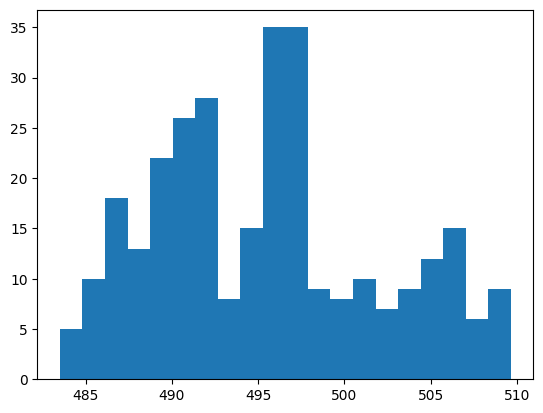

In [61]:
import matplotlib.pyplot as plt
import numpy as np
plt.hist(df.Close,bins=20)
plt.show() 